In [ ]:
# Kaggel testing Notebook

In [ ]:
!pip install -q "monai[nibabel, tqdm]" joblib scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.7 MB/s eta 0:00:00:00:01
ERROR: pip's dependen

In [3]:
import os
BEST_MODEL_PATH = f'/kaggle/input/brats-latest-attention-unet-model/other/default/1/best_model_fold_0_newsba4.pth'
BASE_DIR = '/kaggle/input/brats-testing-datasetsb/BRATS'

RAW_DIR = os.path.join(BASE_DIR, 'train')
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed')

Global_testID = "BraTS-GLI-02405-100"

In [4]:
#Load Model
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.networks.nets import AttentionUnet
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    CropForegroundd,
    Resized,
    ScaleIntensityRanged,
    ConvertToMultiChannelBasedOnBratsClassesd,
    EnsureTyped
)
from skimage.measure import label, marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ==============================================================================
# Part 1: Configuration and Model Loading (Same as before)
# ==============================================================================

# --- Device Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Model Definition ---
model = AttentionUnet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
).to(device)

# --- Load Pre-trained Weights ---
# model.load_state_dict(torch.load(BEST_MODEL_PATH)['model_state_dict'])

map_location = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(BEST_MODEL_PATH, map_location=map_location)
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print("Model loaded successfully.")

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-11-10 14:21:45.817264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762784506.083545      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762784506.165432      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Model loaded successfully.


In [5]:
# ==============================================================================
# Part 2: Preprocessing and Post-Processing Functions (Same as before)
# ==============================================================================

# --- Post-Processing Function ---
def remove_small_lesions(pred_mask_np, min_size_map):
    processed_mask = np.zeros_like(pred_mask_np)
    for c in range(pred_mask_np.shape[0]):
        channel_mask = pred_mask_np[c]
        if np.sum(channel_mask) > 0:
            labeled_mask = label(channel_mask)
            min_size = min_size_map.get(c, 50)
            for region_label in range(1, np.max(labeled_mask) + 1):
                if np.sum(labeled_mask == region_label) > min_size:
                    processed_mask[c][labeled_mask == region_label] = 1
    return processed_mask

# ==============================================================================
# Part 3: Volumetric and 3D Visualization Functions (NEW)
# ==============================================================================
def calculate_and_print_volumes(true_mask, pred_mask, logIt = True):
    """
    Calculates and prints tumor volumes and Dice scores (accuracy) for each class.
    """
    voxel_volume = 1.0  # Assuming 1x1x1mm spacing
    smooth = 1e-6
    labels = ["Tumor Core (TC)", "Whole Tumor (WT)", "Enhancing Tumor (ET)"]

    results = {
        "volumetry": []
    }

    if logIt:
        print("\n--- Volumetric and Accuracy Analysis ---")
        print("-" * 85)
        print(f"{'Tumor Component':<25} | {'Ground Truth Volume':<20} | {'Predicted Volume':<20} | {'Dice Score (Accuracy)':<20}")
        print("-" * 85)

    for i, label_name in enumerate(labels):
        # --- Volume Calculation ---
        true_volume = np.sum(true_mask[i]) * voxel_volume
        pred_volume = np.sum(pred_mask[i]) * voxel_volume

        # --- Dice Score Calculation (based on your provided logic) ---
        true_flat = true_mask[i].flatten()
        pred_flat = pred_mask[i].flatten()
        
        intersection = np.sum(true_flat * pred_flat)
        sum_of_sets = np.sum(true_flat) + np.sum(pred_flat)
        
        dice_score = (2. * intersection + smooth) / (sum_of_sets + smooth)

        # --- Print the combined results for the current class ---
        if logIt:
            print(f"{label_name:<25} | {true_volume:<20.2f} | {pred_volume:<20.2f} | {dice_score:<20.4f}")
            
        results["volumetry"].append({
            "label": label_name,
            "ground_truth_volume": true_volume,
            "predicted_volume": pred_volume,
            "dice_score": dice_score
        })

    if logIt:
        print("-" * 85)
    return results


## Full Run - No Plot

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import json

def runIT(ids, output_dir="volumetry_results"):

    os.makedirs(output_dir, exist_ok=True)
    summary_results = []
    full_results = {}

    print(f"\nRunning volumetry for {len(ids)} patients...\n")
    print(f"{'patient_id':<20} | {'WT Dice':<10} | {'TC Dice':<10} | {'ET Dice':<10} | {'Total Dice (avg)':<16}")
    print("-" * 80)

    for pid in ids:
        patient_path = os.path.join(PROCESSED_DIR, f"{pid}.npz")
        
        try:
            with np.load(patient_path) as data:
                image = torch.from_numpy(data['image'].astype(np.float32))
                true_mask = torch.from_numpy(data['mask'].astype(np.float32))
        except Exception as e:
            print(f"⚠️  Skipping {patient_path} due to error: {e}")
            continue 
    
        input_tensor = image.unsqueeze(0).to(device)
        # Run inference
        with torch.no_grad():
            prediction_logits = model(input_tensor)
            
    
        # Post-process the prediction
        pred_mask_raw = (torch.sigmoid(prediction_logits).cpu().squeeze(0) > 0.5).numpy()
        min_lesion_sizes = {0: 100, 1: 75, 2: 50}  # WT, TC, ET
        pred_mask_postprocessed = remove_small_lesions(pred_mask_raw, min_lesion_sizes)
    
        # Perform Volumetric Analysis ---
        true_mask_np = true_mask.numpy()
        rs = calculate_and_print_volumes(true_mask_np, pred_mask_postprocessed, False)
        rs["patient_id"] = pid
        
        # --- Extract Dice scores ---
        dice_scores = {entry["label"]: entry["dice_score"] for entry in rs["volumetry"]}

        wt_dice = dice_scores.get("Whole Tumor (WT)", np.nan)
        tc_dice = dice_scores.get("Tumor Core (TC)", np.nan)
        et_dice = dice_scores.get("Enhancing Tumor (ET)", np.nan)
        total_dice = np.nanmean([wt_dice, tc_dice, et_dice])

        # --- Append summary row ---
        summary_results.append({
            "patient_id": pid,
            "WT Dice": wt_dice,
            "TC Dice": tc_dice,
            "ET Dice": et_dice,
            "Total Dice (avg)": total_dice
        })

        # --- Store full volumetry data ---
        full_results[pid] = rs  # keep the full dictionary for later inspection

        # --- Print live table row ---
        print(f"{pid:<20} | {wt_dice:<10.4f} | {tc_dice:<10.4f} | {et_dice:<10.4f} | {total_dice:<16.4f}")

    # --- Convert summary to DataFrame ---
    df = pd.DataFrame(summary_results)

    # --- Save full results JSON ---
    full_json_path = os.path.join(output_dir, "full_results.json")
    with open(full_json_path, "w") as f:
        json.dump(full_results, f, indent=4)
    print(f"\n💾 Full results saved to: {full_json_path}")

    # --- Save summary table CSV ---
    summary_csv_path = os.path.join(output_dir, "summary_table.csv")
    df.to_csv(summary_csv_path, index=False)
    print(f"💾 Summary CSV saved to: {summary_csv_path}")

    print("\n✅ Completed volumetry for all patients.\n")
    print(df)

    return df

In [ ]:
files = os.listdir(PROCESSED_DIR)
filesW = [f.split('.')[0] for f in files]
abc = runIT(filesW)

In [ ]:
import pandas as pd
import numpy as np

# Assuming df is your DataFrame returned from runIT()
# Columns: ['patient_id', 'WT Dice', 'TC Dice', 'ET Dice', 'Total Dice (avg)']

# --- Filter out rows where all Dice scores are zero ---
df = abc
df_filtered = df[~((df['WT Dice'] == 0) & (df['TC Dice'] == 0) & (df['ET Dice'] == 0))]

# --- Compute average of each column ---
avg_wt = df_filtered['WT Dice'].mean()
avg_tc = df_filtered['TC Dice'].mean()
avg_et = df_filtered['ET Dice'].mean()
avg_total = df_filtered['Total Dice (avg)'].mean()

# --- Log the average row ---
print("\nAverage Dice scores (ignoring rows with all zeros):")
print(f"{'AVG':<12} | {avg_wt:<10.4f} | {avg_tc:<10.4f} | {avg_et:<10.4f} | {avg_total:<16.4f}")


## Visual with Plot

In [11]:
# ==============================================================================
# Part 3: Preprocessing (NIfTI to NPZ)
# ==============================================================================
# This optimized pipeline converts raw .nii.gz files into processed .npz arrays.
# ------------------------------------------------------------------------------


import numpy as np
from tqdm.notebook import tqdm
import concurrent.futures
from functools import partial
import torch

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, CropForegroundd,
    Resized, ScaleIntensityRanged, ConvertToMultiChannelBasedOnBratsClassesd, EnsureTyped
)

# --- Configuration ---
BASE_DIR = '/kaggle/input/brats-testing-datasetsb/BRATS'
UNZIPPED_DIR = os.path.join(BASE_DIR, 'train')
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed')

TARGET_VOXEL_SPACING = (1.0, 1.0, 1.0)
OUTPUT_SHAPE = (128, 128, 128)
MODALITY_KEYS = ['t1c', 't1n', 't2f', 't2w']
ALL_KEYS = MODALITY_KEYS + ['seg']

os.makedirs(PROCESSED_DIR, exist_ok=True)

# --- Preprocessing Functions ---
def find_patient_files(data_dir):
    patient_files = []
    for patient_id in sorted(os.listdir(data_dir)):
        patient_folder = os.path.join(data_dir, patient_id)
        if os.path.isdir(patient_folder):
            files = {
                "t1c": os.path.join(patient_folder, f"{patient_id}-t1c.nii.gz"),
                "t1n": os.path.join(patient_folder, f"{patient_id}-t1n.nii.gz"),
                "t2f": os.path.join(patient_folder, f"{patient_id}-t2f.nii.gz"),
                "t2w": os.path.join(patient_folder, f"{patient_id}-t2w.nii.gz"),
                "seg": os.path.join(patient_folder, f"{patient_id}-seg.nii.gz"),
                "id": patient_id
            }
            if all(os.path.exists(f) for k, f in files.items() if k != "id"):
                patient_files.append(files)
    return patient_files


monai_preprocess_pipeline = Compose([
    LoadImaged(keys=ALL_KEYS, image_only=True, ensure_channel_first=True),
    ConvertToMultiChannelBasedOnBratsClassesd(keys='seg'),
    Spacingd(keys=ALL_KEYS, pixdim=TARGET_VOXEL_SPACING, mode=["bilinear"] * 4 + ["nearest"]),
    ScaleIntensityRanged(keys=MODALITY_KEYS, a_min=0.0, a_max=1400.0, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=ALL_KEYS, source_key='t1c', margin=10),
    Resized(keys=ALL_KEYS, spatial_size=OUTPUT_SHAPE, mode=["area"] * 4 + ["nearest"]),
    EnsureTyped(keys=ALL_KEYS, dtype=torch.float16) # Use float16 to save disk space
])

def preprocess_and_save(patient_data, output_dir):
    try:
        processed_data = monai_preprocess_pipeline(patient_data)
        final_image = torch.cat([processed_data[key] for key in MODALITY_KEYS], dim=0)
        final_mask = processed_data['seg']
        output_filepath = os.path.join(output_dir, f"{patient_data['id']}.npz")
        np.savez_compressed(output_filepath, image=final_image.numpy(), mask=final_mask.numpy().astype(np.uint8))
    except Exception as e:
        return f"Failed {patient_data['id']}: {e}"
    return None

In [18]:
def plot2D(WT_mask, TC_mask, ET_mask, image_slice, slice_idx, patient_id):
    # 2. Create the figure and axes for the single-row plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Model Prediction for Patient: {patient_id} (Slice {slice_idx})', fontsize=16)
    
    # --- Plot 1: Composite Overlay on the Grayscale Image ---
    # Convert grayscale image to a 3-channel RGB image to serve as a background
    background = np.stack([image_slice] * 3, axis=-1)
    
    # Create a color mask
    # Use different colors to avoid confusion: Red for ET, Green for TC, Blue for WT outline
    color_mask = np.zeros_like(background)
    color_mask[WT_mask == 1] = [0, 0, 1]  # Blue for Whole Tumor
    color_mask[TC_mask == 1] = [1, 0, 0]  # Red for Tumor Core
    color_mask[ET_mask == 1] = [0, 1, 0]  # Green for Enhancing Tumor
    
    # Blend the background and the color mask
    # This gives a much better context than plotting on a black background
    alpha = 0.6
    overlay_image = background * (1 - alpha) + color_mask * alpha
    
    axes[0].imshow(overlay_image)
    axes[0].set_title("All Masks Overlay\n(WT:Blue, TC:Green, ET:Red)")
    axes[0].axis('off')
    
    
    # --- Plot 2: Whole Tumor (WT) ---
    # Displaying the mask alone on a white background using a colormap
    axes[1].imshow(WT_mask, cmap='Blues', interpolation='none')
    axes[1].set_title("Whole Tumor")
    axes[1].axis('off')
    
    # --- Plot 3: Tumor Core (TC) ---
    axes[2].imshow(TC_mask, cmap='Reds', interpolation='none')
    axes[2].set_title("Tumor Core")
    axes[2].axis('off')
    
    # --- Plot 4: Enhancing Tumor (ET) ---
    axes[3].imshow(ET_mask, cmap='Greens', interpolation='none')
    axes[3].set_title("Enhancing Tumor")
    axes[3].axis('off')
    
    # Adjust layout and show the plot
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    

def get_model_output_and_plot(patient_id, model, device, prepro = False, haveGT = True):
    """
    Loads patient data, gets model output, and plots the derived masks.
    """
    
    if prepro:
        patient_path = os.path.join(RAW_DIR, f"{patient_id}")
    else:
        patient_path = os.path.join(PROCESSED_DIR, f"{patient_id}.npz")
    
    if not os.path.exists(patient_path):
        print(f"Patient file not found at {patient_path}")
        return

    # Load and preprocess the data

    if prepro:

        patient_data = {
            "t1c": os.path.join(patient_path, f"{patient_id}-t1c.nii.gz"),
            "t1n": os.path.join(patient_path, f"{patient_id}-t1n.nii.gz"),
            "t2f": os.path.join(patient_path, f"{patient_id}-t2f.nii.gz"),
            "t2w": os.path.join(patient_path, f"{patient_id}-t2w.nii.gz"),
            "seg": os.path.join(patient_path, f"{patient_id}-seg.nii.gz"),
            "id": patient_id
        }

        error = preprocess_and_save(patient_data, PROCESSED_DIR)
        if error:
            print(error)
            return 
        else:
            print(f"Patient {patient_id} processed successfully!")
            
        patient_path = os.path.join(PROCESSED_DIR, f"{patient_id}.npz")
    
    with np.load(patient_path) as data:
        image = torch.from_numpy(data['image'].astype(np.float32))
        true_mask = torch.from_numpy(data['mask'].astype(np.float32))

    input_tensor = image.unsqueeze(0).to(device)
    # Run inference
    with torch.no_grad():
        prediction_logits = model(input_tensor)
        

    # Post-process the prediction
    pred_mask_raw = (torch.sigmoid(prediction_logits).cpu().squeeze(0) > 0.5).numpy()
    min_lesion_sizes = {0: 100, 1: 75, 2: 50}  # WT, TC, ET
    pred_mask_postprocessed = remove_small_lesions(pred_mask_raw, min_lesion_sizes)

    # Perform Volumetric Analysis ---
    true_mask_np = true_mask.numpy()
    calculate_and_print_volumes(true_mask_np, pred_mask_postprocessed)
    
    # 1. Select the middle slice to display
    slice_idx = image.shape[-1] // 2

    depth = 128
    best_slice_et = None
    max_voxels_et = 0
    
    for i in range(depth):
        voxels_et = np.count_nonzero(true_mask[2, :, :, i])
        if voxels_et > max_voxels_et:
            max_voxels_et = voxels_et
            best_slice_et = i
    
    print("Slice index where ET mask is biggest:", best_slice_et)
    print("Number of ET voxels in that slice:", max_voxels_et)
    
    if best_slice_et:
        slice_idx = best_slice_et
    
    
    image_slice = image[0, :, :, slice_idx]

    # True Plot
    print("GROUND TRUTH PLOT")
    WT_mask = true_mask[1, :, :, slice_idx]
    TC_mask = true_mask[0, :, :, slice_idx]
    ET_mask = true_mask[2, :, :, slice_idx]
    plot2D(WT_mask, TC_mask, ET_mask, image_slice, slice_idx, patient_id)

    # Pred Plot (With Lesions)
    print("GROUND TRUTH PLOT (With Lesions)")
    WT_mask = pred_mask_raw[1, :, :, slice_idx]
    TC_mask = pred_mask_raw[0, :, :, slice_idx]
    ET_mask = pred_mask_raw[2, :, :, slice_idx]
    plot2D(WT_mask, TC_mask, ET_mask, image_slice, slice_idx, patient_id)

    # Pred Plot (Without Lesions)
    print("Pred PLOT (Without Lesions)")
    WT_mask = pred_mask_postprocessed[1, :, :, slice_idx]
    TC_mask = pred_mask_postprocessed[0, :, :, slice_idx]
    ET_mask = pred_mask_postprocessed[2, :, :, slice_idx]
    plot2D(WT_mask, TC_mask, ET_mask, image_slice, slice_idx, patient_id)
    
    return pred_mask_postprocessed


--- Volumetric and Accuracy Analysis ---
-------------------------------------------------------------------------------------
Tumor Component           | Ground Truth Volume  | Predicted Volume     | Dice Score (Accuracy)
-------------------------------------------------------------------------------------
Tumor Core (TC)           | 7011.00              | 6168.00              | 0.5899              
Whole Tumor (WT)          | 37846.00             | 26524.00             | 0.7535              
Enhancing Tumor (ET)      | 5151.00              | 2907.00              | 0.5905              
-------------------------------------------------------------------------------------
Slice index where ET mask is biggest: 67
Number of ET voxels in that slice: 353
GROUND TRUTH PLOT


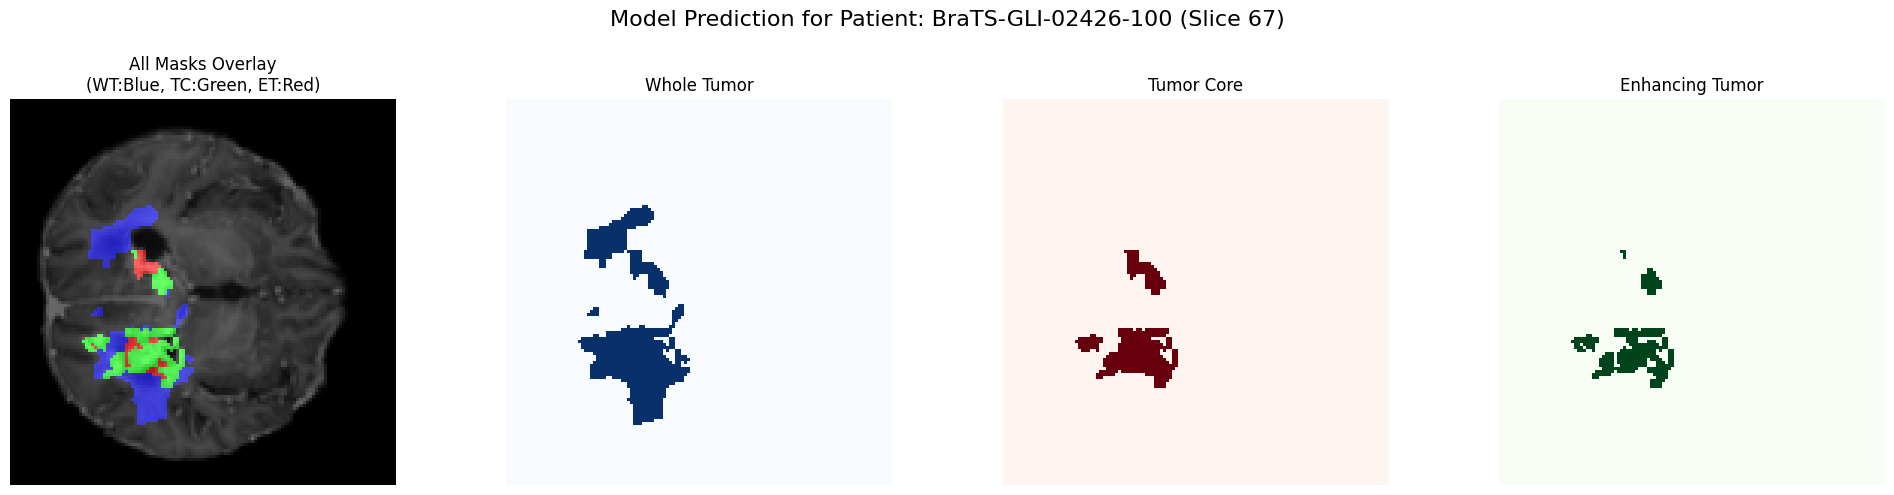

GROUND TRUTH PLOT (With Lesions)


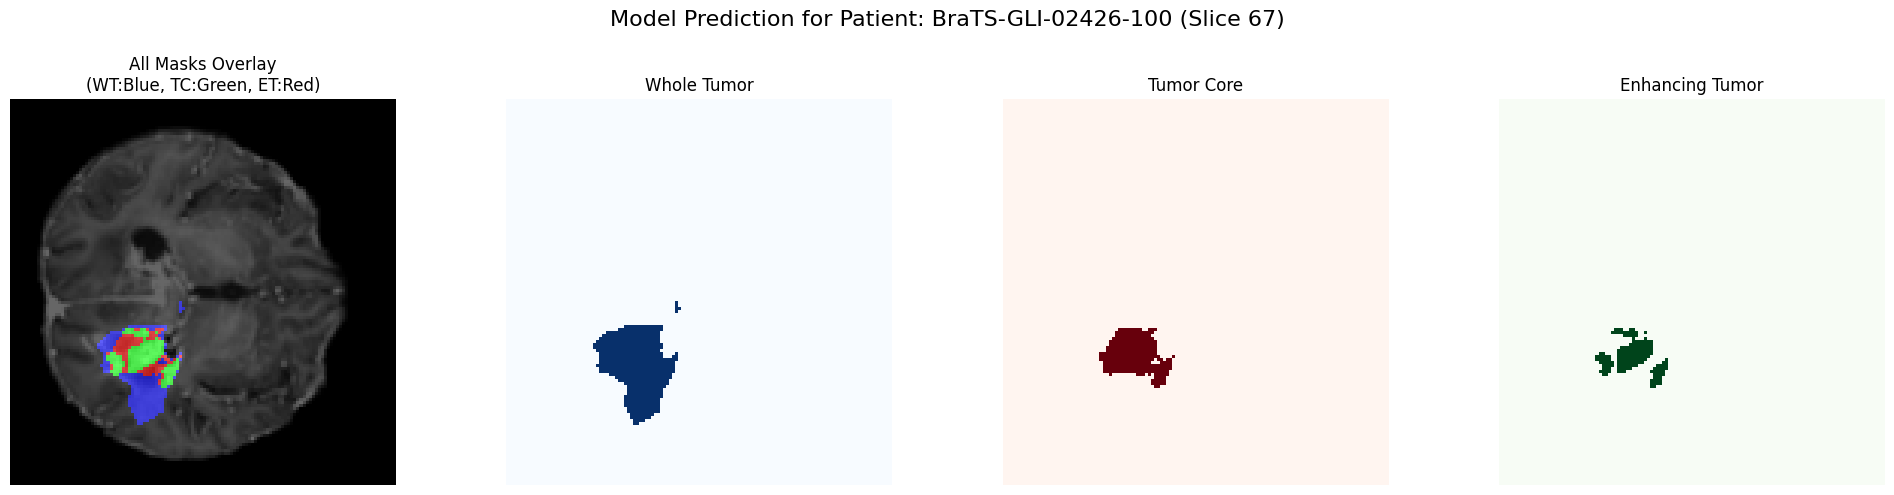

Pred PLOT (Without Lesions)


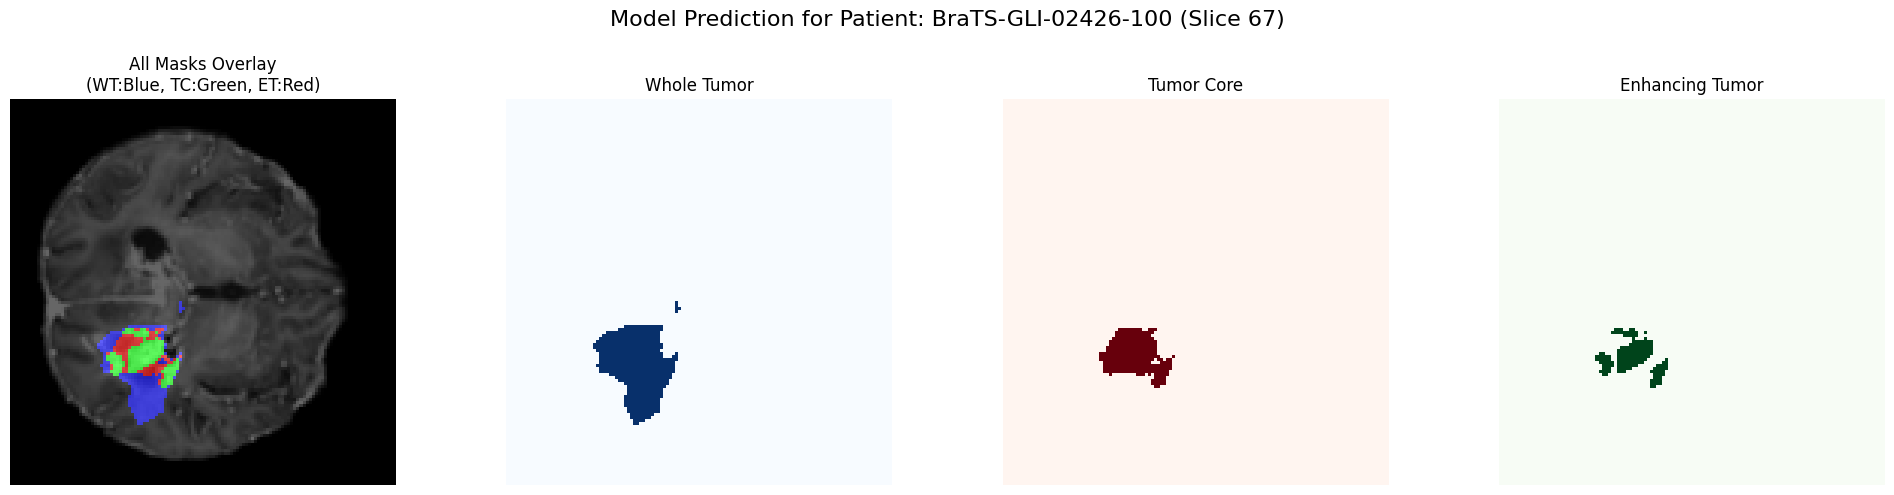

In [22]:
testId = Global_testID
abc = get_model_output_and_plot("BraTS-GLI-02426-100", model, device)

# /kaggle/input/brats-testing-datasetsb/BRATS/processed/BraTS-GLI-02405-100.npz